In [1]:
import warnings
warnings.filterwarnings("ignore")
import pickle
import mne
import neurokit2 as nk2
import time
import math
import glob, sys, os 
import numpy as np
import scipy as sp
from scipy.stats import shapiro
import seaborn as sns
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.colors as mcolors
import joblib
import fooof as fooof
from fooof import FOOOF
import ordpy 
import logging
from scipy.stats import pearsonr, ttest_ind
import itertools
from statannotations.Annotator import Annotator

from scipy.stats import mannwhitneyu

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from scipy.stats import shapiro
from scipy.stats import levene
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import roc_curve, auc

logging.getLogger('mne').setLevel(logging.WARNING)
pd.set_option('display.max_rows', 500)

# Get Info 

In [2]:
# Load demographics + bx data 
in_dir = '/Users/derek/Documents/PICU/Manuscript_analysis/'
output_dir = f'{in_dir}/Manuscript Redo/Figures/'

metric_o_i = ['SampEn','PEn','CWPEn','LZC_PSN', 'LZC', 'LE','HiguchiFD','dfa','dfaDelta','dfaTheta','dfaAlpha',
              'FOOOF_Offset','FOOOF_Slope', '|delta|Power', 'delta_RelPower','|theta|Power','theta_RelPower','|alpha|Power',
              'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower']

metric_interested = ['SampEn','PEn','CWPEn','LZC','LE','HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power','|alpha|Power', '|beta|Power', '|low-gamma|Power',]

# Define metric_names dictionary for proper naming
metric_names = {
    "SampEn": "Sample Entropy",
    "PEn": "Permutation Entropy",
    "CWPEn": "Conditional Weighted Permutation Entropy",
    "LZC_PSN": "Lempel-Ziv Complexity-Phase Shuffled",
    "LZC": "Lempel-Ziv Complexity",
    "LE": "Lyapunov Exponent",
    "HiguchiFD": "Higuchi Fractal Dimension",
    "dfa": "Detrended Fluctuation Analysis",
    "dfaDelta": "Detrended Fluctuation Analysis Delta",
    "dfaTheta": "Detrended Fluctuation Analysis Theta",
    "dfaAlpha": "Detrended Fluctuation Analysis Alpha",
    "FOOOF_Offset": "Spectral Slope Offset",
    "FOOOF_Slope": "Spectral Slope",
    "|delta|Power": "Absolute Delta Power",
    "delta_RelPower": "Delta Relative Power",
    "|theta|Power": "Absolute Theta Power",
    "theta_RelPower": "Relative Theta Power",
    "|alpha|Power": "Absolute Alpha Power",
    "alpha_RelPower": "Relative Alpha Power",
    "|beta|Power": "Absolute Beta Power",
    "beta_RelPower": "Relative Beta Power",
    "|low-gamma|Power": "Absolute Gamma Power",
    "low-gamma_RelPower": "Relative Gamma Power",
}

# Define metrics of interest
metric_interested = ['SampEn', 'PEn', 'CWPEn', 'LZC', 'LE', 'HiguchiFD', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', '|theta|Power', '|alpha|Power', '|beta|Power', '|low-gamma|Power']

def extract_participant_id(file):
    return file[:9]
    
#vis_dem = pd.read_csv("/Users/derek/Documents/PICU/Manuscript_analysis/Visual_df.csv")
demo_csv = f'{in_dir}/PICU_DEMO_Clean.csv'
demos = pd.read_csv(demo_csv)
demos = demos.drop(['Unnamed: 16','Unnamed: 17'], axis=1)
demos = demos.drop([41])
filtered_data_age = demos[demos['age_years'] <= 5][['participant_id']]
filtered_data_gose = demos[demos['GOSE_3mo'].isna() | (demos['GOSE_3mo'] == '') | ~np.isfinite(demos['GOSE_3mo'])][['participant_id']]
filtered_data_age_gose = demos[
    (demos['age_years'] >= 5) & 
    (demos['GOSE_3mo'].notna()) & 
    (demos['GOSE_3mo'] != '')]

print(f"# Old Metrics {len(metric_o_i)}, # New Metrics {len(metric_interested)}")
ordered_file = f"{in_dir}/all_temporal_order.csv"
ordered_files_csv = pd.read_csv(ordered_file)
output_filename = f"{in_dir}/all_data_name.pkl"

print(f"Data retrieved from {output_filename}")
with open(output_filename, 'rb') as input_file:
    all_data_name_loaded = pickle.load(input_file)

orig_keys_all_files = all_data_name_loaded.keys()

base_files = []
for i in orig_keys_all_files:
    if "ase" in i:
        base_files.append(i)
for i in orig_keys_all_files:
    filename = i
    if "HM" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "ent" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
for i in orig_keys_all_files:
    filename = i
    if "orphine" in filename and not any(substring in filename for substring in ["ro", "id", "ex"]):
        base_files.append(filename)
        
sed_files = []
for i in orig_keys_all_files:
    filename = i
    if filename not in base_files:
        if "Ket" not in filename:
            sed_files.append(filename)
prop_files = []
for i in sed_files:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files.append(filename)
mid_files = []
for i in sed_files:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files.append(filename)
dex_mix_files = []
for i in sed_files:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files.append(filename)

# naming is off, is rop, for the processed files to have drop added in changes my naming and how i searched through 
# total ordered files listed from raw is 393
print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files)) # 56 propofol 
print("Mid files: ",len(mid_files)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files)) # 67 various 

print(all_data_name_loaded['sub-001AC_Baseline_pre_sed_drop_chs_'].keys())

all_data_name = all_data_name_loaded
all_data_median = {}
for file, data in all_data_name.items():
    metrics = []
    for metric in metric_o_i:
        med_met = np.median(all_data_name[file][metric])
        metrics.append(med_met)
    all_data_median[file] = metrics

sedation_data = {}
for i,k in all_data_median.items():
    if i in sed_files:
        sedation_data[i] =k

#sedation_data
prop_data = {}
for i,k in all_data_median.items():
    if i in prop_files:
        prop_data[i] =k
mid_data = {}
for i,k in all_data_median.items():
    if i in mid_files:
        mid_data[i] =k
dex_mix_data = {}
for i,k in all_data_median.items():
    if i in dex_mix_files:
        dex_mix_data[i] =k

# Old Metrics 23, # New Metrics 14
Data retrieved from /Users/derek/Documents/PICU/Manuscript_analysis//all_data_name.pkl
All files:  366
Base files:  82
Sed files:  266
Prop files:  56
Mid files:  143
Dex_mix files:  67
dict_keys(['SampEn', 'PEn', 'CWPEn', 'LZC_PSN', 'LZC', 'LE', 'HiguchiFD', 'dfa', 'dfaDelta', 'dfaTheta', 'dfaAlpha', 'FOOOF_Offset', 'FOOOF_Slope', '|delta|Power', 'delta_RelPower', '|theta|Power', 'theta_RelPower', '|alpha|Power', 'alpha_RelPower', '|beta|Power', 'beta_RelPower', '|low-gamma|Power', 'low-gamma_RelPower'])


# HANDLE PROPER KEYS AND DUPLICATES 

In [ ]:
goodkeys = []
for key, data in all_data_name.items():
    if key in sedation_data.keys():
        print(key)
        goodkeys.append(key)
len(goodkeys)

# Testing normality 


In [4]:
from scipy.stats import shapiro

# Initialize results dictionary
results = {}

for participant, metrics in all_data_name.items():
    if participant in sedation_data.keys():
        results[participant] = {}
        for metric, values in metrics.items():
            # Perform Shapiro-Wilk test for normality
            shapiro_stat, shapiro_p = shapiro(values)
            
            # Calculate variance
            variance = np.var(values, ddof=1)  # ddof=1 for sample variance
            
            # Store results
            results[participant][metric] = {
                'Shapiro_Stat': shapiro_stat,
                'Shapiro_P': shapiro_p,
                'Variance': variance
            }

# Convert results to a DataFrame for easy handling
all_results = []
for participant, metrics in results.items():
    for metric, stats in metrics.items():
        all_results.append({
            'Participant': participant,
            'Metric': metric,
            'Shapiro_Stat': stats['Shapiro_Stat'],
            'Shapiro_P': stats['Shapiro_P'],
            'Variance': stats['Variance']
        })

results_df = pd.DataFrame(all_results)

# Add significance flag for Shapiro-Wilk test
results_df['Normality'] = results_df['Shapiro_P'] > 0.05  # True if data is normally distributed

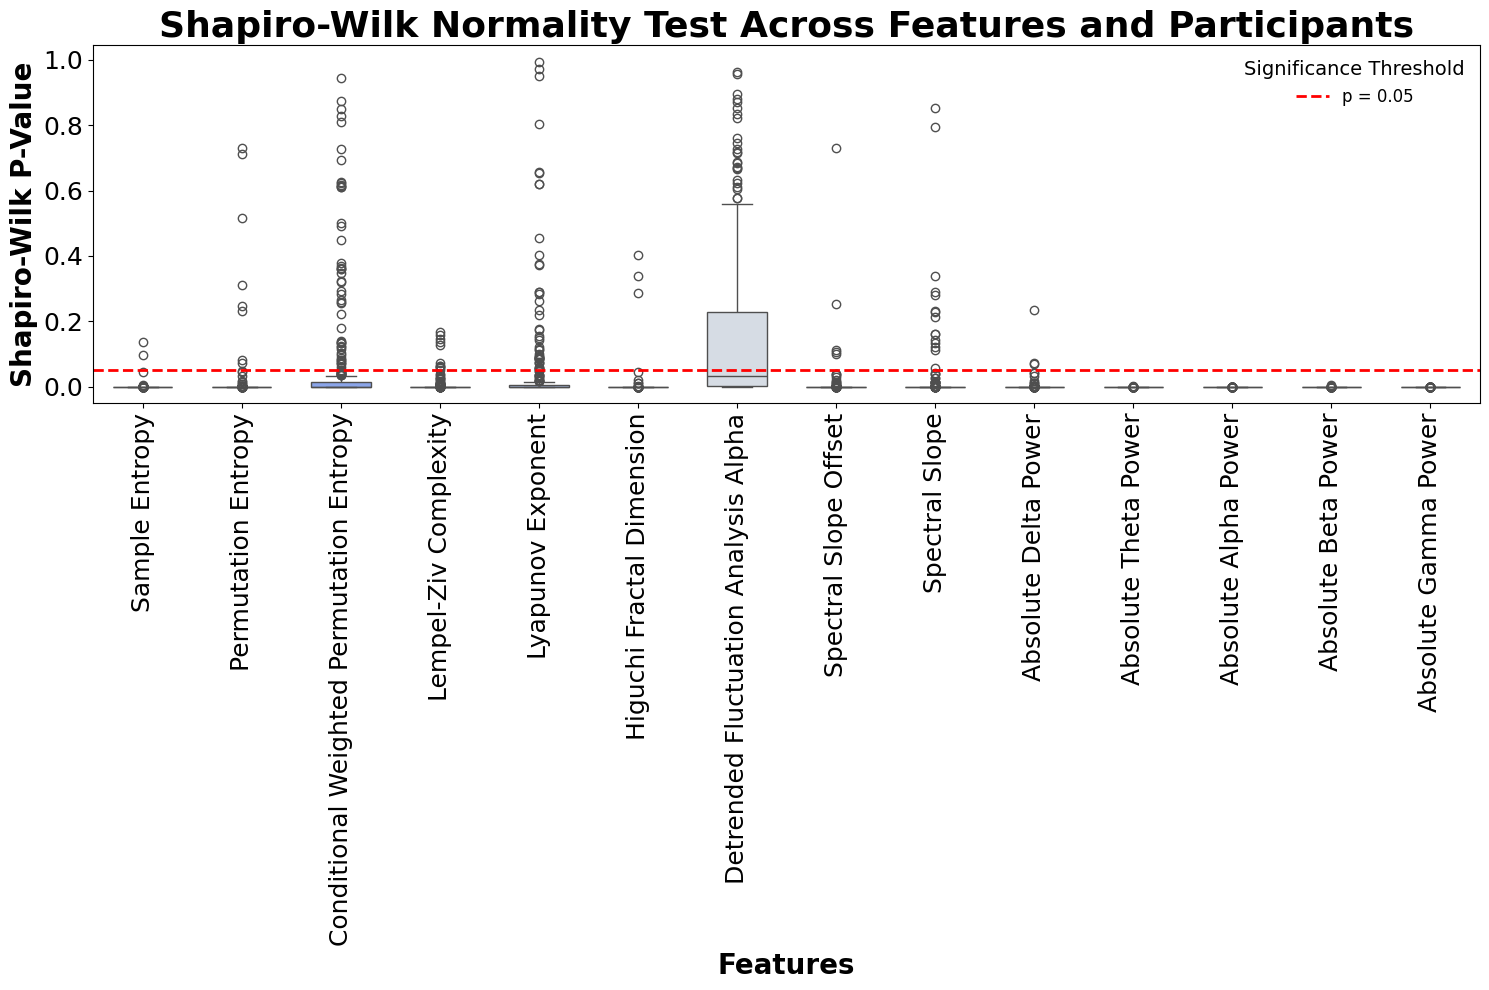

In [5]:
test_norm = results_df[results_df['Metric'].isin(metric_interested)]
test_norm['Metric'] = test_norm['Metric'].replace(metric_names)
metric_plots = ["Sample Entropy","Permutation Entropy","Conditional Weighted Permutation Entropy", "Lempel-Ziv Complexity","Lyapunov Exponent", "Higuchi Fractal Dimension",
                "Detrended Fluctuation Analysis Alpha","Spectral Slope Offset","Spectral Slope","Absolute Delta Power","Absolute Theta Power","Absolute Alpha Power","Absolute Beta Power","Absolute Gamma Power"]

plt.figure(figsize=(15, 10))
sns.boxplot(data=test_norm, x='Metric', y='Shapiro_P',width=0.6, palette='coolwarm')
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='p = 0.05')
plt.xticks(rotation=90, fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('Features', fontsize=20, fontweight='bold')
plt.ylabel('Shapiro-Wilk P-Value', fontsize=20, fontweight='bold')
plt.title('Shapiro-Wilk Normality Test Across Features and Participants', fontsize=26, fontweight='bold')
plt.legend(loc='upper right', fontsize=12, title='Significance Threshold', title_fontsize=14, frameon=False)
plt.tight_layout()
#plt.savefig(f"/Users/derek/Documents/PICU/Manuscript_analysis/Manuscript Redo/Figures/tif_figures/variance_boxplot.tif", dpi=600, format='tif')
plt.show()



# Delete Duplicates and Patients without Data 

In [6]:
sed_ids = []
for i in sed_files:
    idx= i[:9]
    sed_ids.append(idx)

unique_ids_sed = np.unique(np.array(sed_ids))

print(f"# patients with Sed: {len(unique_ids_sed)}")

# Who does not have GOSE 
excluded_subs = ['sub-023MC', 'sub-002AC', 'sub-004AC', 'sub-005AC', 'sub-007AC', 'sub-008AC','sub-010AC',
                 'sub-001MC','sub-002MC','sub-003MC','sub-004MC','sub-005MC', 'sub-007MC','sub-009MC','sub-010MC','sub-012MC','sub-024MC','sub-006AC','sub-012AC']

bx_ids = list(filtered_data_age_gose['participant_id'])

new_seds = []
for i in sed_files:
    if all(sub not in i for sub in excluded_subs) and i not in new_seds:
        new_seds.append(i)

unique_ids = set()
for item in new_seds:
    unique_id = item.split('_')[0]
    unique_ids.add(unique_id)
unique_ids = list(unique_ids)

print(len(unique_ids))

prop_files_UP = []
for i in new_seds:
    filename = i
    if "rop" in filename and not any(substring in filename for substring in ["id", "ex"]):
        prop_files_UP.append(filename)
mid_files_UP = []
for i in new_seds:
    filename = i
    if "id" in filename and not any(substring in filename for substring in ["rop", "ex"]):
        mid_files_UP.append(filename)
dex_mix_files_UP = []
for i in new_seds:
    filename = i
    if filename not in prop_files:
        if filename not in mid_files:
            dex_mix_files_UP.append(filename)

print("All files: ", len(orig_keys_all_files)) # all data is 366
print("Base files: ",len(base_files)) # 82 files = baselines, fent only nad HM only, Morphine
print("Sed files: ",len(sed_files), " Now:", len(new_seds)) # Sed is 266 without the ketamine (18 files)
print("Prop files: ",len(prop_files), " Now:", len(prop_files_UP)) # 56 propofol 
print("Mid files: ",len(mid_files), " Now:", len(mid_files_UP)) # 143 mid
print("Dex_mix files: ",len(dex_mix_files), " Now:", len(dex_mix_files_UP)) # 67 various 

# patients with Sed: 49
32
All files:  366
Base files:  82
Sed files:  266  Now: 175
Prop files:  56  Now: 24
Mid files:  143  Now: 104
Dex_mix files:  67  Now: 47


In [7]:
filtered_demos = demos[demos['participant_id'].isin(unique_ids)]
vis_dem = filtered_demos
vis_dem['injury_etiology_cleaned'] = vis_dem['Etiology']

age_min = int(vis_dem['age_years'].min())
age_max = int(vis_dem['age_years'].max())
age_mean = vis_dem['age_years'].mean()
age_std = vis_dem['age_years'].std()
print(f"The ages of participants ranged from {age_min} years to {age_max} years, with a mean age of {age_mean:.2f} years (standard deviation: {age_std:.2f} years).")

The ages of participants ranged from 6 years to 16 years, with a mean age of 11.34 years (standard deviation: 3.19 years).


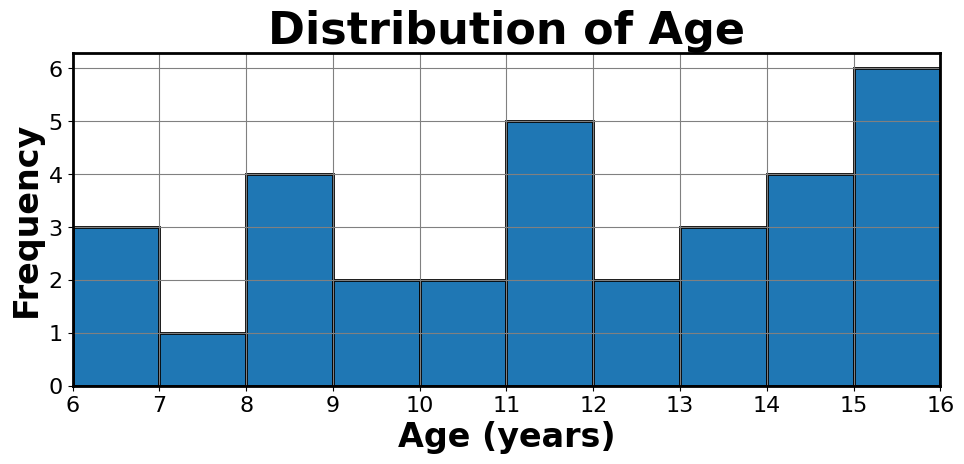

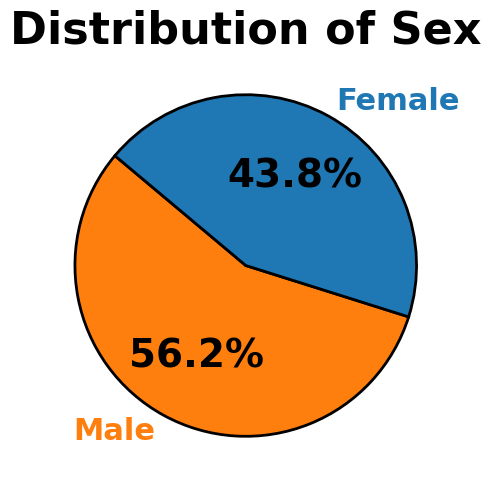

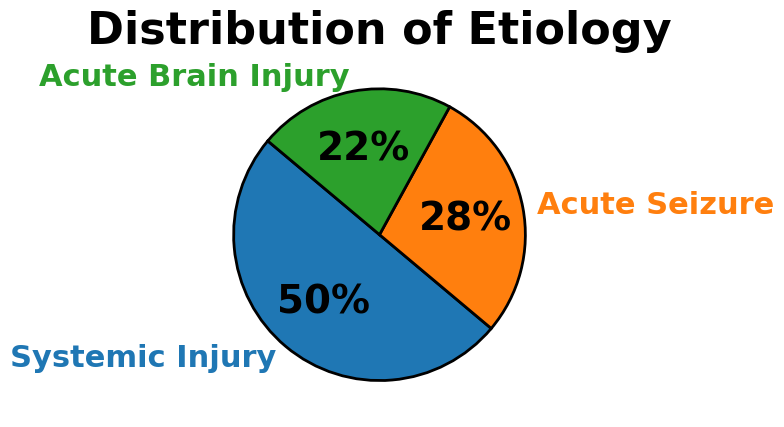

In [8]:
# Demographics figures

# Age Distribution Histogram
plt.figure(figsize=(10, 5))
plt.hist(vis_dem['age_years'],rwidth=1.0,histtype='bar', edgecolor='black',linewidth=2)
plt.title("Distribution of Age", fontsize=32,fontweight='bold')
plt.xlabel("Age (years)", fontsize=24,fontweight='bold')
plt.ylabel("Frequency", fontsize=24,fontweight='bold')
age_min = int(vis_dem['age_years'].min())
age_max = int(vis_dem['age_years'].max())
plt.xticks(np.arange(age_min, age_max + 1, step=1), fontsize=16)  
plt.yticks(fontsize=16)
plt.grid(color='grey')
plt.xlim(age_min, age_max) 
for spine in plt.gca().spines.values():
    spine.set_linewidth(2)  # Set thickness of the plot outline
    spine.set_edgecolor('black')
plt.tight_layout(pad=2)
#plt.savefig(f"{output_dir}age_distribution.png", dpi=300)  
plt.show()

plt.figure(figsize=(5, 5))
# Pie Chart for Sex Distribution
sex_counts = vis_dem['Sex'].value_counts()
labels = ['Male', 'Female']
sizes = sex_counts.values
colors =['#ff7f0e','#1f77b4'] 

wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140, 
    wedgeprops=dict(edgecolor='black', linewidth=2),  # Thicker wedge outlines
    textprops=dict(fontsize=22, fontweight='bold')  # Bold text for labels
)

plt.title("Distribution of Sex", fontsize=32, fontweight='bold')
for text, autotext, color in zip(texts, autotexts, colors):
    text.set_color(color)  # Set the label text color to match the wedge color
    autotext.set_color('black')  # Set the percentage text color to match the wedge color
    autotext.set_fontsize(28)  # Adjust the font size of the percentages
    autotext.set_fontweight('bold')  # Make the percentage text bold
plt.tight_layout()
#plt.savefig(f"{output_dir}sex_distribution_pie.png", dpi=300)  
plt.show()



plt.figure(figsize=(8, 8))

# Pie Chart for Etiology Distribution
etiology_counts = vis_dem['Etiology'].value_counts()
labels = etiology_counts.index.str.title()
sizes = etiology_counts.values
colors = plt.get_cmap('tab10').colors
wedges, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.0f%%', 
    startangle=140, 
    wedgeprops=dict(edgecolor='black', linewidth=2), 
    textprops=dict(fontsize=22, fontweight='bold')  
)
plt.title("Distribution of Etiology", fontsize=32, fontweight='bold')
for text, autotext, color in zip(texts, autotexts, colors):
    text.set_color(color)  # Set the label text color to match the wedge color
    autotext.set_color('black')  # Set the percentage text color to black
    autotext.set_fontsize(28)  # Adjust the font size of the percentages
    autotext.set_fontweight('bold')  # Make the percentage text bold

plt.tight_layout(pad=4)
#plt.savefig(f"{output_dir}Etiology_distribution_pie.png", dpi=300)  
plt.show()